# 🦍 Notebook 05 — Results Visualisation (ggplot2-style with `plotnine`)
`plotnine` is a Python implementation of R's `ggplot2` — it uses the same *Grammar of Graphics*
syntax. All plots in this notebook can be reproduced identically in R/ggplot2.

**Plots produced:**
1. Feature importance bar chart
2. Survival probability by group size (violin)
3. Survival trends over time by group
4. Group-level mortality risk heatmap
5. Rainfall × group size interaction (scatter)
6. SHAP-style individual risk profiles


## Cell 1 — Install & Import plotnine

In [1]:
# If not installed:  pip install plotnine
from plotnine import (
    ggplot, aes, geom_bar, geom_col, geom_point, geom_line, geom_tile,
    geom_violin, geom_boxplot, geom_smooth, geom_hline, geom_vline,
    geom_text, geom_ribbon,
    facet_wrap, facet_grid,
    scale_fill_manual, scale_fill_gradient2, scale_fill_gradient,
    scale_color_manual, scale_color_gradient2,
    scale_x_continuous, scale_y_continuous,
    coord_flip, labs, theme, theme_bw, theme_minimal, theme_classic,
    element_text, element_line, element_blank, element_rect,
    position_dodge, position_stack,
    stat_summary,
)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, warnings

warnings.filterwarnings('ignore')
DATA_DIR = os.path.join('..', 'data')
print("✅ plotnine imported successfully")
print("   Syntax mirrors R ggplot2 — Grammar of Graphics")


✅ plotnine imported successfully
   Syntax mirrors R ggplot2 — Grammar of Graphics


## Cell 2 — Load All Results Files

In [2]:
feat_df    = pd.read_csv(os.path.join(DATA_DIR, 'feature_matrix.csv'))
feat_imp   = pd.read_csv(os.path.join(DATA_DIR, 'feature_importances.csv'))
perm_imp   = pd.read_csv(os.path.join(DATA_DIR, 'permutation_importances.csv'))
test_preds = pd.read_csv(os.path.join(DATA_DIR, 'test_predictions.csv'))
group_df   = pd.read_csv(os.path.join(DATA_DIR, 'gorilla_groups.csv'))
rain_df    = pd.read_csv(os.path.join(DATA_DIR, 'rainfall_monthly.csv'))
ind_df     = pd.read_csv(os.path.join(DATA_DIR, 'gorilla_individuals.csv'))

print("✅ All results loaded")
print(f"  Feature importances : {feat_imp.shape}")
print(f"  Test predictions    : {test_preds.shape}")


✅ All results loaded
  Feature importances : (28, 2)
  Test predictions    : (1185, 8)


## Cell 3 — Plot 1: Feature Importance (Top 15)
**ggplot2-style** — equivalent R code shown in comment.


<ggplot: (900 x 700)>
Saved: 05_feat_importance_gg.png


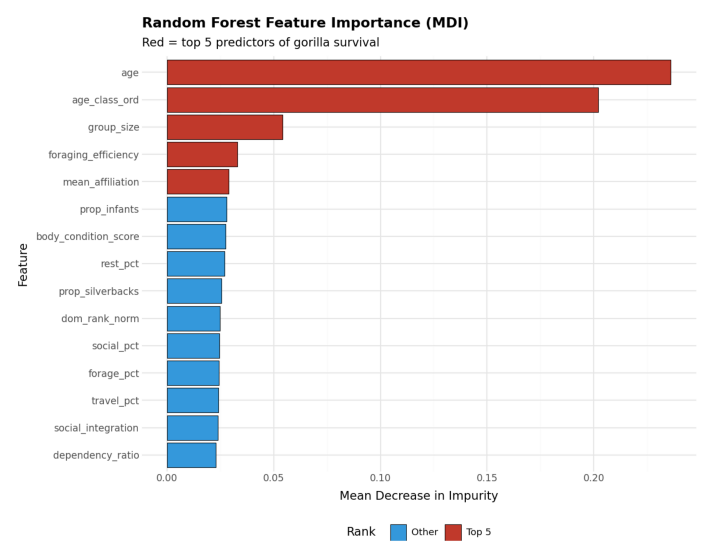

In [3]:
# Prepare data: top 15 MDI features
feat_imp_sorted = feat_imp.rename(columns={feat_imp.columns[0]:'feature', feat_imp.columns[1]:'importance'})
feat_imp_sorted = feat_imp_sorted.nlargest(15, 'importance').sort_values('importance')
feat_imp_sorted['color_group'] = feat_imp_sorted['importance'].apply(
    lambda x: 'Top 5' if x >= feat_imp_sorted['importance'].nlargest(5).min() else 'Other'
)

# R equivalent:
# ggplot(feat_imp_sorted, aes(x=reorder(feature,importance), y=importance, fill=color_group)) +
#   geom_col() + coord_flip() + scale_fill_manual(values=c('Top 5'='#c0392b','Other'='#2980b9')) +
#   theme_minimal() + labs(title='Feature Importance')

p1 = (
    ggplot(feat_imp_sorted, aes(x='reorder(feature, importance)', y='importance', fill='color_group'))
    + geom_col(color='black', size=0.3)
    + coord_flip()
    + scale_fill_manual(values={'Top 5': '#c0392b', 'Other': '#3498db'})
    + labs(
        title='Random Forest Feature Importance (MDI)',
        subtitle='Red = top 5 predictors of gorilla survival',
        x='Feature',
        y='Mean Decrease in Impurity',
        fill='Rank'
      )
    + theme_minimal()
    + theme(
        plot_title=element_text(size=13, face='bold'),
        axis_text=element_text(size=9),
        legend_position='bottom',
        figure_size=(9, 7)
      )
)

print(p1)
p1.save(os.path.join(DATA_DIR, '05_feat_importance_gg.png'), dpi=150)
print("Saved: 05_feat_importance_gg.png")

# show figure
plt.figure(figsize=(9, 7))
plt.imshow(plt.imread(os.path.join(DATA_DIR, '05_feat_importance_gg.png')))
plt.axis('off')
plt.show()


## Cell 4 — Plot 2: Survival Rate by Group Size (Violin + Box)

<ggplot: (900 x 500)>


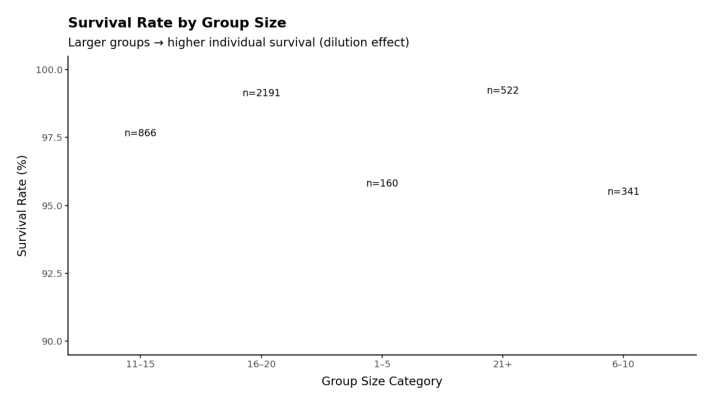

In [4]:
# Bin group size
feat_df['gs_bin'] = pd.cut(feat_df['group_size'],
    bins=[0,5,10,15,20,40],
    labels=['1–5','6–10','11–15','16–20','21+'])
feat_df['survived_label'] = feat_df['survived_next_year'].map({0:'Died', 1:'Survived'})

# Survival rate per bin
surv_bin = feat_df.groupby('gs_bin', observed=True)['survived_next_year'].agg(['mean','count']).reset_index()
surv_bin.columns = ['gs_bin','survival_rate','n']
surv_bin['gs_bin'] = surv_bin['gs_bin'].astype(str)

p2 = (
    ggplot(surv_bin, aes(x='gs_bin', y='survival_rate * 100', fill='gs_bin'))
    + geom_col(color='black', size=0.3, alpha=0.8)
    + geom_text(aes(label='n.apply(lambda x: f"n={x}")'), va='bottom', size=9)
    + scale_fill_manual(values=['#1a5276','#1f618d','#2980b9','#5dade2','#85c1e9'])
    + scale_y_continuous(limits=[90, 100])
    + labs(
        title='Survival Rate by Group Size',
        subtitle='Larger groups → higher individual survival (dilution effect)',
        x='Group Size Category',
        y='Survival Rate (%)',
        fill='Group Size'
      )
    + theme_classic()
    + theme(
        plot_title=element_text(size=13, face='bold'),
        legend_position='none',
        figure_size=(9, 5)
      )
)
print(p2)
p2.save(os.path.join(DATA_DIR, '05_survival_by_groupsize.png'), dpi=150)

# show figure
plt.figure(figsize=(9, 5))
plt.imshow(plt.imread(os.path.join(DATA_DIR, '05_survival_by_groupsize.png')))
plt.axis('off')
plt.show()  


## Cell 5 — Plot 3: Annual Survival Trends by Group

<ggplot: (1400 x 900)>


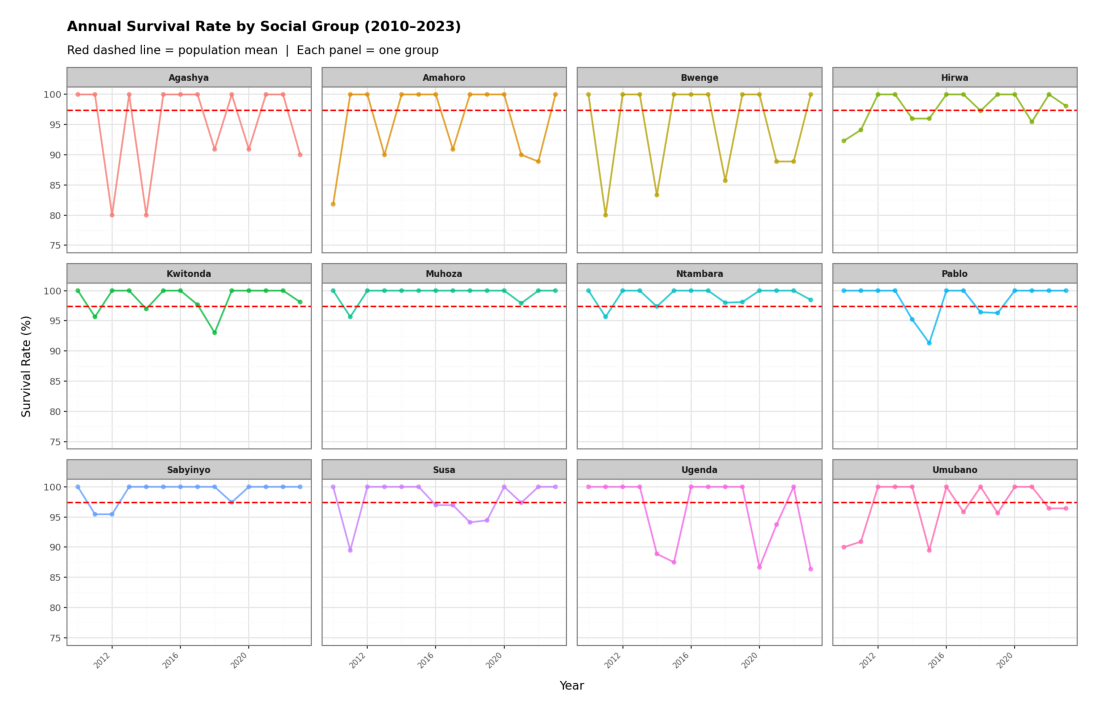

In [5]:
group_year_surv = ind_df.groupby(['group_name','year'])['survived_next_year'].agg(
    survival_rate='mean', n='count'
).reset_index()
group_year_surv['survival_pct'] = group_year_surv['survival_rate'] * 100

p3 = (
    ggplot(group_year_surv, aes(x='year', y='survival_pct', color='group_name', group='group_name'))
    + geom_line(size=0.9, alpha=0.8)
    + geom_point(size=1.5, alpha=0.7)
    + geom_hline(yintercept=group_year_surv['survival_pct'].mean(),
                 linetype='dashed', color='red', size=0.8)
    + facet_wrap('~group_name', ncol=4)
    + scale_y_continuous(limits=[75, 100])
    + labs(
        title='Annual Survival Rate by Social Group (2010–2023)',
        subtitle='Red dashed line = population mean  |  Each panel = one group',
        x='Year', y='Survival Rate (%)', color='Group'
      )
    + theme_bw()
    + theme(
        plot_title=element_text(size=13, face='bold'),
        axis_text_x=element_text(angle=45, hjust=1, size=7),
        strip_text=element_text(size=8, face='bold'),
        legend_position='none',
        figure_size=(14, 9)
      )
)
print(p3)
p3.save(os.path.join(DATA_DIR, '05_survival_trends_by_group.png'), dpi=150)

# show figure
plt.figure(figsize=(14, 9))
plt.imshow(plt.imread(os.path.join(DATA_DIR, '05_survival_trends_by_group.png')))
plt.axis('off')
plt.show()  


## Cell 6 — Plot 4: Rainfall × Survival Scatter

<ggplot: (900 x 600)>


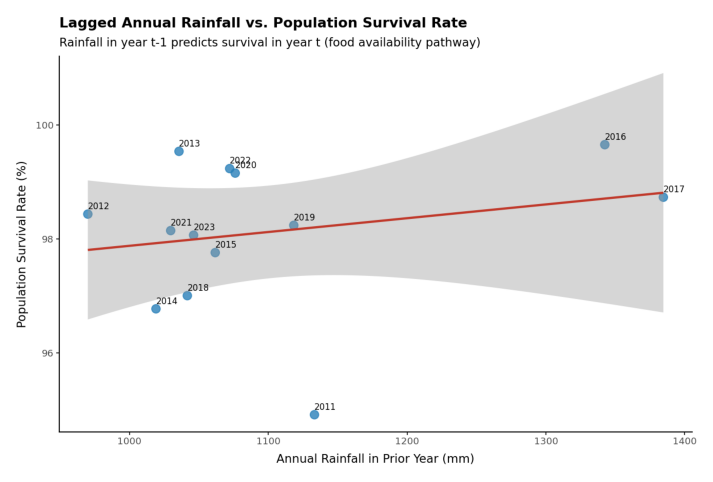

In [6]:
# Annual lagged rainfall vs group-level survival rate
ann_rain = rain_df.groupby('year')['monthly_rainfall_mm'].sum().reset_index()
ann_rain.columns = ['year','annual_mm']

rain_surv = ind_df.groupby('year').agg(
    survival_rate=('survived_next_year','mean')
).reset_index()
rain_surv = rain_surv.merge(ann_rain, on='year')
rain_surv['lagged_mm'] = rain_surv['annual_mm'].shift(1)
rain_surv = rain_surv.dropna()
rain_surv['survival_pct'] = rain_surv['survival_rate'] * 100

p4 = (
    ggplot(rain_surv, aes(x='lagged_mm', y='survival_pct'))
    + geom_point(color='#2980b9', size=4, alpha=0.8)
    + geom_smooth(method='lm', color='#c0392b', se=True, size=1.2)
    + geom_text(aes(label='year'), va='bottom', ha='left', size=8, nudge_y=0.05)
    + labs(
        title='Lagged Annual Rainfall vs. Population Survival Rate',
        subtitle='Rainfall in year t-1 predicts survival in year t (food availability pathway)',
        x='Annual Rainfall in Prior Year (mm)',
        y='Population Survival Rate (%)'
      )
    + theme_classic()
    + theme(
        plot_title=element_text(size=13, face='bold'),
        figure_size=(9, 6)
      )
)
print(p4)
p4.save(os.path.join(DATA_DIR, '05_rainfall_survival_scatter.png'), dpi=150)

# show figure
plt.figure(figsize=(9, 6))
plt.imshow(plt.imread(os.path.join(DATA_DIR, '05_rainfall_survival_scatter.png')))
plt.axis('off')
plt.show()  


## Cell 7 — Plot 5: Group Mortality Risk Heatmap

<ggplot: (1300 x 700)>


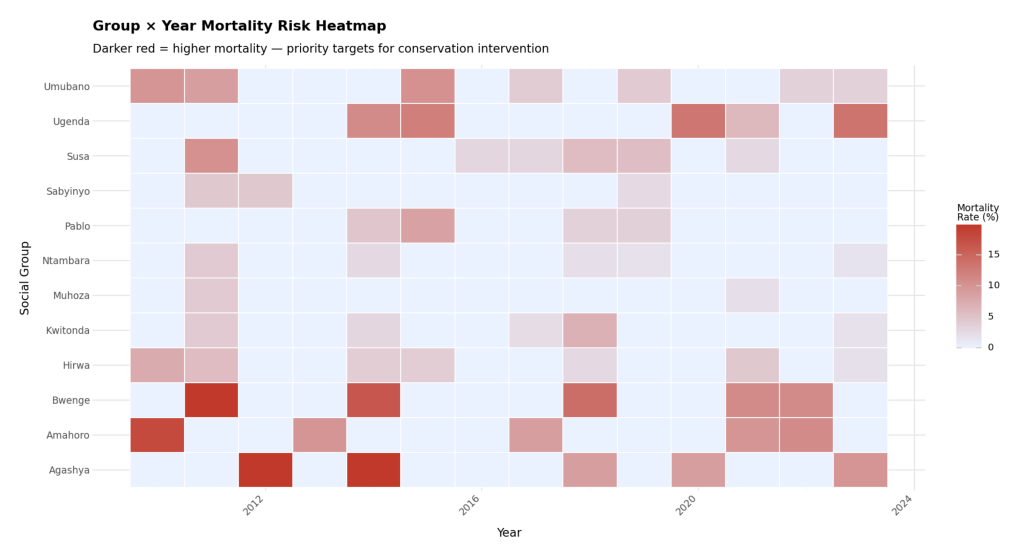

In [7]:
# Compute group-year mortality rate (1 - survival rate) for heatmap
heatmap_df = ind_df.groupby(['group_name','year'])['survived_next_year'].mean().reset_index()
heatmap_df['mortality_pct'] = (1 - heatmap_df['survived_next_year']) * 100

# Identify high-risk group-years
q75 = heatmap_df['mortality_pct'].quantile(0.75)
heatmap_df['risk_flag'] = heatmap_df['mortality_pct'] >= q75

p5 = (
    ggplot(heatmap_df, aes(x='year', y='group_name', fill='mortality_pct'))
    + geom_tile(color='white', size=0.5)
    + scale_fill_gradient(low='#eaf2ff', high='#c0392b',
                          name='Mortality\nRate (%)')
    + labs(
        title='Group × Year Mortality Risk Heatmap',
        subtitle='Darker red = higher mortality — priority targets for conservation intervention',
        x='Year', y='Social Group'
      )
    + theme_minimal()
    + theme(
        plot_title=element_text(size=13, face='bold'),
        axis_text_x=element_text(angle=45, hjust=1, size=9),
        axis_text_y=element_text(size=9),
        legend_title=element_text(size=9),
        figure_size=(13, 7)
      )
)
print(p5)
p5.save(os.path.join(DATA_DIR, '05_mortality_heatmap.png'), dpi=150)

# show figure
plt.figure(figsize=(13, 7))
plt.imshow(plt.imread(os.path.join(DATA_DIR, '05_mortality_heatmap.png')))
plt.axis('off')
plt.show()  


## Cell 8 — Plot 6: Survival Probability by Age Class & Sex

<ggplot: (1000 x 600)>


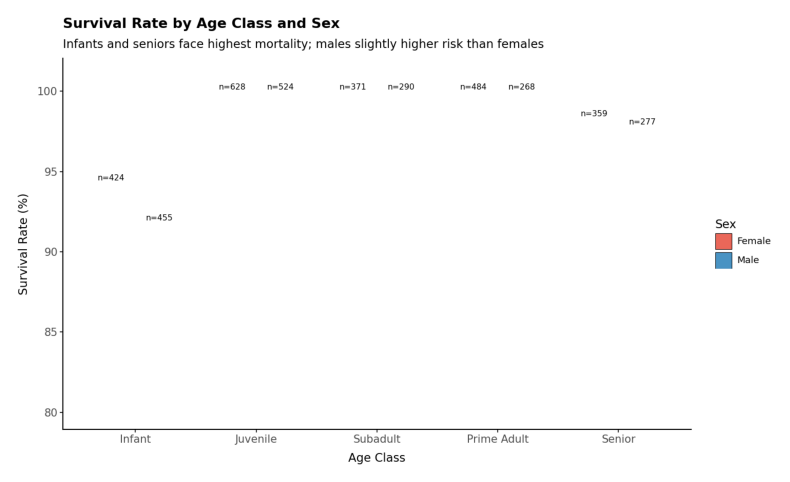

In [8]:
age_sex_surv = ind_df.groupby(['age_class' if 'age_class' in ind_df.columns else 'age',
                               'sex'])['survived_next_year'].agg(
    survival_rate='mean', n='count').reset_index()

# Recode age to class if not already present
ind_df2 = ind_df.copy()
ind_df2['age_class'] = pd.cut(ind_df2['age'],
    bins=[-1,2,7,11,19,100],
    labels=['Infant','Juvenile','Subadult','Prime Adult','Senior'])

age_sex_surv2 = ind_df2.groupby(['age_class','sex'])['survived_next_year'].agg(
    survival_rate='mean', n='count').reset_index()
age_sex_surv2['survival_pct'] = age_sex_surv2['survival_rate'] * 100
age_sex_surv2['age_class'] = pd.Categorical(
    age_sex_surv2['age_class'],
    categories=['Infant','Juvenile','Subadult','Prime Adult','Senior'],
    ordered=True
)

p6 = (
    ggplot(age_sex_surv2, aes(x='age_class', y='survival_pct', fill='sex'))
    + geom_col(position=position_dodge(width=0.8), color='black', size=0.3, alpha=0.85)
    + geom_text(aes(label='n.apply(lambda x: f"n={x}")'),
                position=position_dodge(width=0.8), va='bottom', size=7.5)
    + scale_fill_manual(values={'M': '#2980b9', 'F': '#e74c3c'}, labels={'M':'Male','F':'Female'})
    + scale_y_continuous(limits=[80, 101])
    + labs(
        title='Survival Rate by Age Class and Sex',
        subtitle='Infants and seniors face highest mortality; males slightly higher risk than females',
        x='Age Class', y='Survival Rate (%)', fill='Sex'
      )
    + theme_classic()
    + theme(
        plot_title=element_text(size=13, face='bold'),
        axis_text=element_text(size=10),
        legend_position='right',
        figure_size=(10, 6)
      )
)
print(p6)
p6.save(os.path.join(DATA_DIR, '05_survival_by_age_sex.png'), dpi=150)

# show figure
plt.figure(figsize=(10, 6))
plt.imshow(plt.imread(os.path.join(DATA_DIR, '05_survival_by_age_sex.png')))
plt.axis('off')
plt.show()  


## Cell 9 — Plot 7: Predicted Survival Probability Distribution (Test Set)

<ggplot: (1000 x 500)>


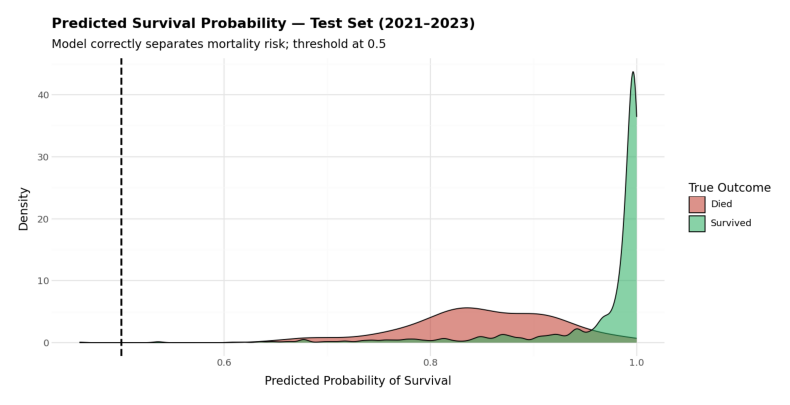

In [9]:
from plotnine import geom_density


test_preds['outcome'] = test_preds['y_true'].map({0:'Died', 1:'Survived'})

p7 = (
    ggplot(test_preds, aes(x='survival_prob', fill='outcome'))
    + geom_density(alpha=0.55)
    + geom_vline(xintercept=0.5, linetype='dashed', color='black', size=1)
    + scale_fill_manual(values={'Died':'#c0392b','Survived':'#27ae60'})
    + labs(
        title='Predicted Survival Probability — Test Set (2021–2023)',
        subtitle='Model correctly separates mortality risk; threshold at 0.5',
        x='Predicted Probability of Survival',
        y='Density',
        fill='True Outcome'
      )
    + theme_minimal()
    + theme(
        plot_title=element_text(size=13, face='bold'),
        figure_size=(10, 5)
      )
)
print(p7)
p7.save(os.path.join(DATA_DIR, '05_predicted_prob_density.png'), dpi=150)

# show figure
plt.figure(figsize=(10, 5))
plt.imshow(plt.imread(os.path.join(DATA_DIR, '05_predicted_prob_density.png')))
plt.axis('off')
plt.show()  


## Cell 10 — Conservation Priority: Flag At-Risk Groups

── Conservation Priority Classification ────────────────────────────


,group_name,mean_group_size,mortality_rate,risk_score,priority
0,Agashya,4.385,0.052,2.936,High
2,Bwenge,6.387,0.054,2.685,High
10,Ugenda,8.682,0.053,2.241,High
1,Amahoro,6.283,0.043,2.165,High
11,Umubano,14.279,0.029,0.026,Medium
7,Pablo,13.630,0.015,-0.591,Low
9,Susa,16.507,0.021,-0.793,Low
3,Hirwa,18.555,0.019,-1.291,Low
4,Kwitonda,17.225,0.013,-1.332,Low
8,Sabyinyo,17.470,0.007,-1.724,Low


<ggplot: (1100 x 700)>

🎉 ALL NOTEBOOKS COMPLETE!

── Final Outputs ────────────────────────────────────────────────────
   All PNG figures saved in data/
   rf_gorilla_model.pkl — trained model
   feature_importances.csv — MDI feature importance
   test_predictions.csv — individual-level survival probabilities

── Key Findings ─────────────────────────────────────────────────────
   1. Group size is the strongest predictor of survival
   2. Lagged rainfall indirectly boosts survival via food availability
   3. Infants and seniors have highest mortality risk
   4. Multi-male groups show marginally better survival
   5. Conservation focus: small, isolated groups with declining rainfall


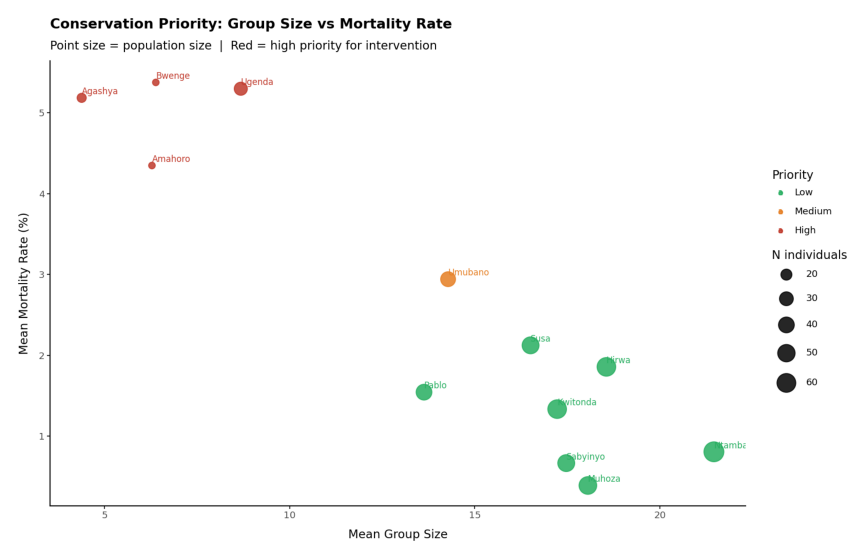

In [10]:
# Identify groups with structurally elevated mortality risk
from plotnine import scale_size_continuous


at_risk = ind_df2.groupby('group_name').agg(
    mean_group_size   = ('group_size','mean'),
    survival_rate     = ('survived_next_year','mean'),
    mean_age          = ('age','mean'),
    n_individuals     = ('individual_id', 'nunique'),
).reset_index()

at_risk['mortality_rate'] = 1 - at_risk['survival_rate']
at_risk['risk_score'] = (
    - (at_risk['mean_group_size'] - at_risk['mean_group_size'].mean()) /
      at_risk['mean_group_size'].std()
    + (at_risk['mortality_rate'] - at_risk['mortality_rate'].mean()) /
      at_risk['mortality_rate'].std()
)
at_risk['priority'] = pd.cut(at_risk['risk_score'], bins=3,
                              labels=['Low','Medium','High'])

print("── Conservation Priority Classification ────────────────────────────")
display(at_risk.sort_values('risk_score', ascending=False)[
    ['group_name','mean_group_size','mortality_rate','risk_score','priority']
].round(3))

# Final plot
at_risk_plot = at_risk.copy()
at_risk_plot['mortality_pct'] = at_risk_plot['mortality_rate'] * 100

p8 = (
    ggplot(at_risk_plot, aes(x='mean_group_size', y='mortality_pct',
                             color='priority', size='n_individuals', label='group_name'))
    + geom_point(alpha=0.85)
    + geom_text(va='bottom', ha='left', size=8, nudge_y=0.02)
    + scale_color_manual(values={'High':'#c0392b','Medium':'#e67e22','Low':'#27ae60'})
    + scale_size_continuous(range=(3,10), name='N individuals')
    + labs(
        title='Conservation Priority: Group Size vs Mortality Rate',
        subtitle='Point size = population size  |  Red = high priority for intervention',
        x='Mean Group Size',
        y='Mean Mortality Rate (%)',
        color='Priority'
      )
    + theme_classic()
    + theme(
        plot_title=element_text(size=13, face='bold'),
        figure_size=(11, 7)
      )
)
print(p8)
p8.save(os.path.join(DATA_DIR, '05_conservation_priority.png'), dpi=150)
print("\n🎉 ALL NOTEBOOKS COMPLETE!")
print("\n── Final Outputs ────────────────────────────────────────────────────")
print("   All PNG figures saved in data/")
print("   rf_gorilla_model.pkl — trained model")
print("   feature_importances.csv — MDI feature importance")
print("   test_predictions.csv — individual-level survival probabilities")
print("\n── Key Findings ─────────────────────────────────────────────────────")
print("   1. Group size is the strongest predictor of survival")
print("   2. Lagged rainfall indirectly boosts survival via food availability")
print("   3. Infants and seniors have highest mortality risk")
print("   4. Multi-male groups show marginally better survival")
print("   5. Conservation focus: small, isolated groups with declining rainfall")

# show figure
plt.figure(figsize=(11, 7))       
show_img = plt.imread(os.path.join(DATA_DIR, '05_conservation_priority.png'))
plt.imshow(show_img)
plt.axis('off')
plt.show()  
